<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Indian Premier League Score Prediction**

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from datetime import datetime 
from sklearn.preprocessing import scale, StandardScaler, RobustScaler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from scipy.stats import randint, uniform, loguniform
import warnings
warnings.simplefilter(action = 'ignore')
sns.set()
plt.style.use('ggplot')
%matplotlib inline

In [2]:
df = pd.read_csv('Indian Premier League Score Prediction - Dataset.csv')
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,18/04/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,18/04/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,18/04/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,18/04/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,18/04/2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [3]:
df.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [4]:
df.shape

(76014, 15)

In [5]:
df.dtypes

mid                 int64
date               object
venue              object
bat_team           object
bowl_team          object
batsman            object
bowler             object
runs                int64
wickets             int64
overs             float64
runs_last_5         int64
wickets_last_5      int64
striker             int64
non-striker         int64
total               int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [7]:
omitted_columns = ['mid', 'venue', 'batsman', 'bowler', 'striker', 'non-striker']
df.drop(labels = omitted_columns, axis = 1, inplace = True)

df.shape

(76014, 9)

In [8]:
df.columns

Index(['date', 'bat_team', 'bowl_team', 'runs', 'wickets', 'overs',
       'runs_last_5', 'wickets_last_5', 'total'],
      dtype='object')

In [9]:
df.index

RangeIndex(start=0, stop=76014, step=1)

In [10]:
df['bat_team'].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Deccan Chargers', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Daredevils',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant'], dtype=object)

In [11]:
consistent_teams = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
                    'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
                    'Delhi Daredevils', 'Sunrisers Hyderabad']
df = df[(df['bat_team'].isin(consistent_teams)) & (df['bowl_team'].isin(consistent_teams))]

df.shape

(53811, 9)

In [12]:
df['bat_team'].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
       'Delhi Daredevils', 'Sunrisers Hyderabad'], dtype=object)

In [13]:
df = df[df['overs'] >= 5.0]

df.shape

(40108, 9)

In [14]:
df['date'] = df['date'].apply(lambda x: datetime.strptime(x, '%d/%m/%Y'))

df.dtypes

date              datetime64[ns]
bat_team                  object
bowl_team                 object
runs                       int64
wickets                    int64
overs                    float64
runs_last_5                int64
wickets_last_5             int64
total                      int64
dtype: object

In [15]:
numerical_columns = df.drop(['date', 'bat_team', 'bowl_team', 'total'], axis = 1)
categorical_columns = df.drop(['runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'total'], axis = 1)

In [16]:
df_numerical = df.select_dtypes(include = ['number']) 
df_categorical = df.select_dtypes(include = ['object', 'category', 'datetime64[ns]'])

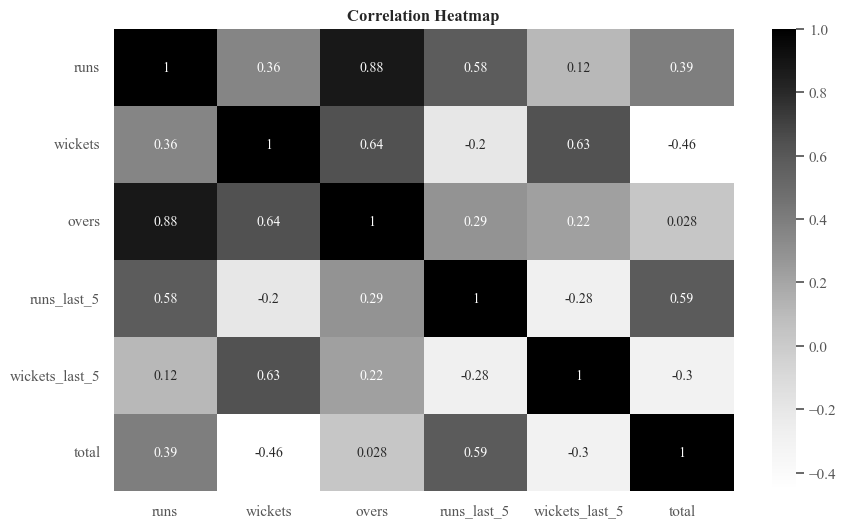

In [17]:
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

correlation_matrix = df_numerical.corr()
top_correlation_features = correlation_matrix.index

fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(data = df_numerical[top_correlation_features].corr(), annot = True, cmap = 'Greys', ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.grid(False)

plt.show()

In [18]:
df.columns

Index(['date', 'bat_team', 'bowl_team', 'runs', 'wickets', 'overs',
       'runs_last_5', 'wickets_last_5', 'total'],
      dtype='object')

In [19]:
outliers_overview = {}

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_overview[column] = len(outliers)

outliers_overview

{'runs': 83,
 'wickets': 982,
 'overs': 0,
 'runs_last_5': 545,
 'wickets_last_5': 1339}

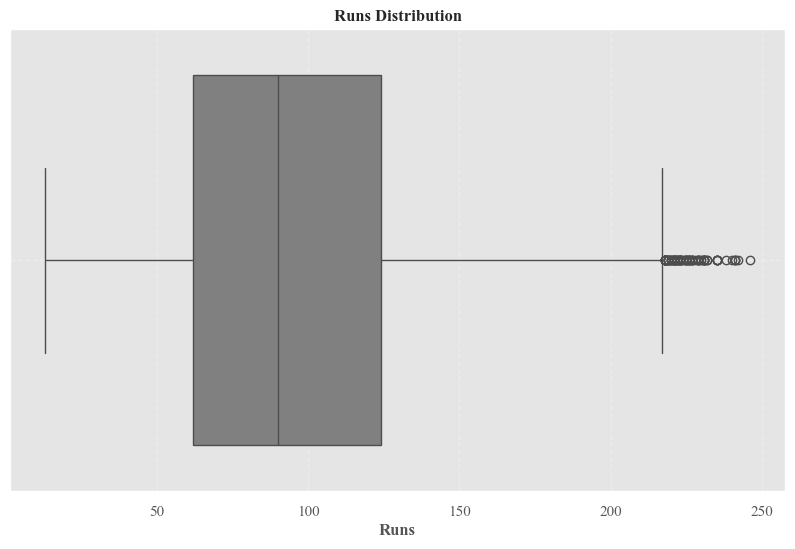

In [20]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['runs'], color = 'grey', ax = ax)
ax.set_title('Runs Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Runs', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

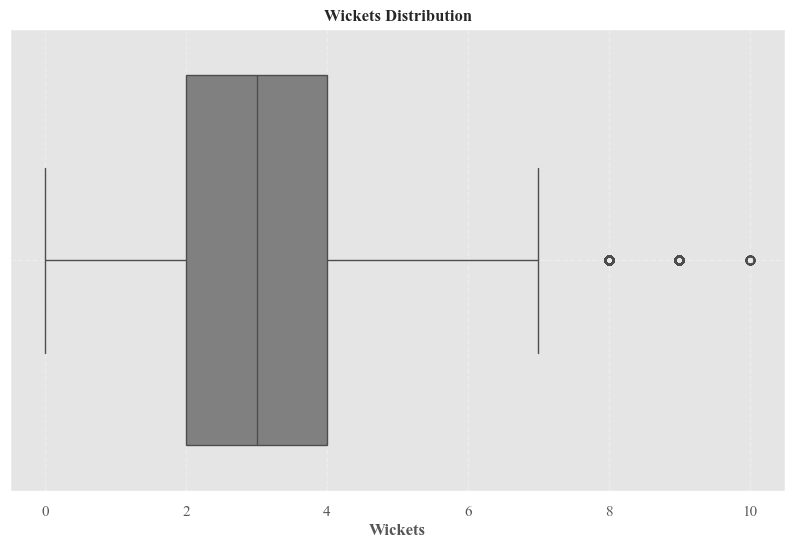

In [21]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['wickets'], color = 'grey', ax = ax)
ax.set_title('Wickets Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Wickets', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

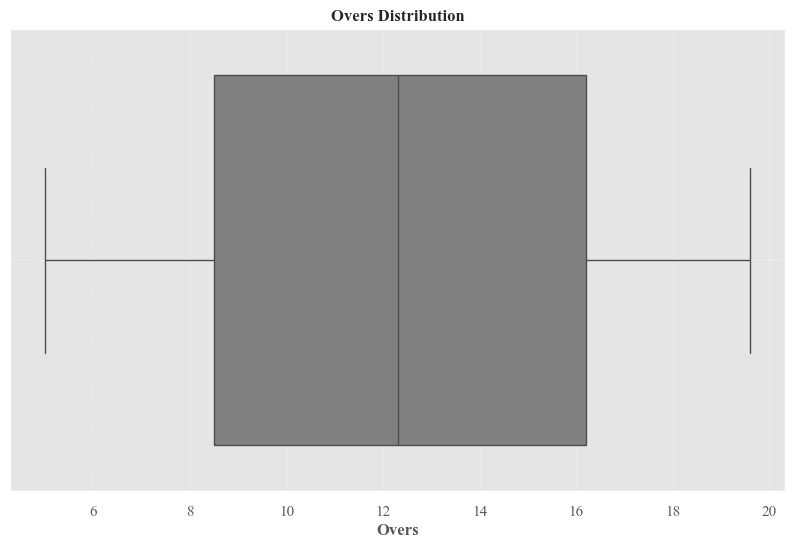

In [22]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['overs'], color = 'grey', ax = ax)
ax.set_title('Overs Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Overs', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

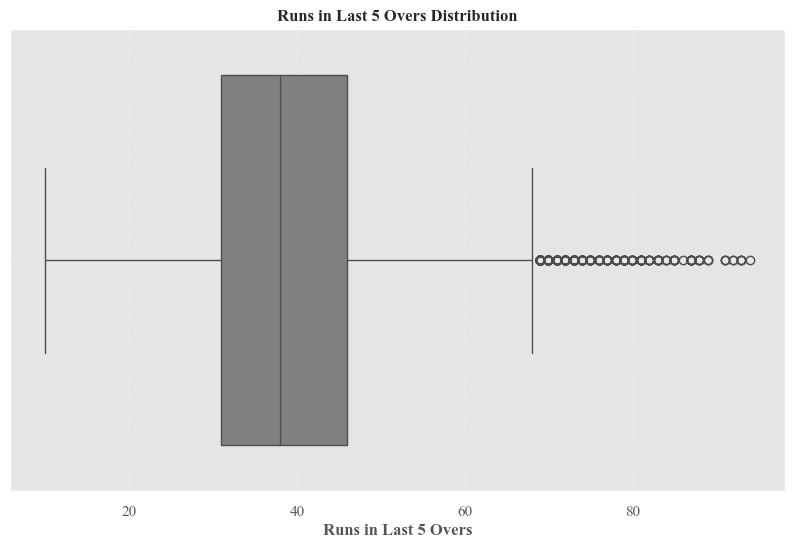

In [23]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['runs_last_5'], color = 'grey', ax = ax)
ax.set_title('Runs in Last 5 Overs Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Runs in Last 5 Overs', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

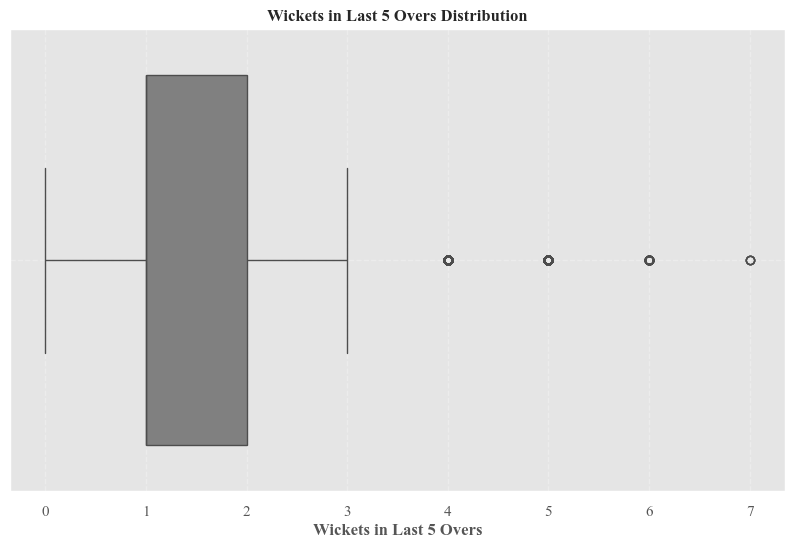

In [24]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['wickets_last_5'], color = 'grey', ax = ax)
ax.set_title('Wickets in Last 5 Overs Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Wickets in Last 5 Overs', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

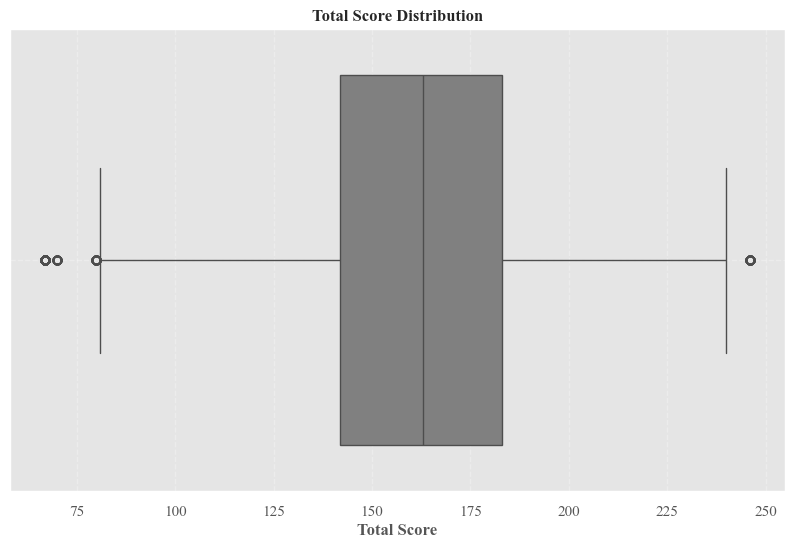

In [25]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['total'], color = 'grey', ax = ax)
ax.set_title('Total Score Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Total Score', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [26]:
df = pd.get_dummies(data = df, columns = ['bat_team', 'bowl_team'], dtype = int)
df.columns

Index(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'total', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
       'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils',
       'bowl_team_Kings XI Punjab', 'bowl_team_Kolkata Knight Riders',
       'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
       'bowl_team_Royal Challengers Bangalore',
       'bowl_team_Sunrisers Hyderabad'],
      dtype='object')

In [27]:
df.head()

,date,runs,wickets,overs,runs_last_5,wickets_last_5,total,bat_team_Chennai Super Kings,bat_team_Delhi Daredevils,bat_team_Kings XI Punjab,...,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,bowl_team_Delhi Daredevils,bowl_team_Kings XI Punjab,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad
32,2008-04-18,61,0,5.1,59,0,222,0,0,0,...,0,0,0,0,0,0,0,0,1,0
33,2008-04-18,61,1,5.2,59,1,222,0,0,0,...,0,0,0,0,0,0,0,0,1,0
34,2008-04-18,61,1,5.3,59,1,222,0,0,0,...,0,0,0,0,0,0,0,0,1,0
35,2008-04-18,61,1,5.4,59,1,222,0,0,0,...,0,0,0,0,0,0,0,0,1,0
36,2008-04-18,61,1,5.5,58,1,222,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [28]:
df = df[['date', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils', 'bat_team_Kings XI Punjab',
         'bat_team_Kolkata Knight Riders', 'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
         'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
         'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils', 'bowl_team_Kings XI Punjab',
         'bowl_team_Kolkata Knight Riders', 'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
         'bowl_team_Royal Challengers Bangalore', 'bowl_team_Sunrisers Hyderabad',
         'overs', 'runs', 'wickets', 'runs_last_5', 'wickets_last_5', 'total']]

In [29]:
df.head()

,date,bat_team_Chennai Super Kings,bat_team_Delhi Daredevils,bat_team_Kings XI Punjab,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,bat_team_Rajasthan Royals,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Chennai Super Kings,...,bowl_team_Mumbai Indians,bowl_team_Rajasthan Royals,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad,overs,runs,wickets,runs_last_5,wickets_last_5,total
32,2008-04-18,0,0,0,1,0,0,0,0,0,...,0,0,1,0,5.1,61,0,59,0,222
33,2008-04-18,0,0,0,1,0,0,0,0,0,...,0,0,1,0,5.2,61,1,59,1,222
34,2008-04-18,0,0,0,1,0,0,0,0,0,...,0,0,1,0,5.3,61,1,59,1,222
35,2008-04-18,0,0,0,1,0,0,0,0,0,...,0,0,1,0,5.4,61,1,59,1,222
36,2008-04-18,0,0,0,1,0,0,0,0,0,...,0,0,1,0,5.5,61,1,58,1,222


In [30]:
X_train = df.drop(labels = 'total', axis = 1)[df['date'].dt.year <= 2016].copy()
X_test = df.drop(labels = 'total', axis = 1)[df['date'].dt.year >= 2017].copy()
y_train = df[df['date'].dt.year <= 2016]['total'].values
y_test = df[df['date'].dt.year >= 2017]['total'].values
X_train.drop(labels = 'date', axis = 1, inplace = True)
X_test.drop(labels = 'date', axis = 1, inplace = True)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(37330, 21) (2778, 21) (37330,) (2778,)


In [31]:
knn_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('model', KNeighborsRegressor())])

knn_params = {'model__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10],
              'model__weights': ['uniform', 'distance'],
              'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'model__leaf_size': [10, 20, 30, 40, 50],
              'model__p': [1, 2, 3]}

knn_grid_search = GridSearchCV(knn_pipeline, param_grid = knn_params, cv = 5,
                               scoring = 'neg_root_mean_squared_error', n_jobs = -1)
knn_grid_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
knn_grid_search.best_params_

In [ ]:
print(knn_grid_search.best_score_)

In [ ]:
knn = knn_grid_search.best_estimator_
y_pred = knn.predict(X_test)
print('K-Nearest Neighbours')
knn_mse = mean_squared_error(y_test, y_pred)
knn_rmse = root_mean_squared_error(y_test, y_pred)
knn_mae = mean_absolute_error(y_test, y_pred)
knn_mape = mean_absolute_percentage_error(y_test, y_pred)
knn_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {knn_mse}')
print(f'Root Mean Squared Error: {knn_rmse}')
print(f'Mean Absolute Error: {knn_mae}')
print(f'Mean Absolute Percentage Error: {knn_mape}')
print(f'R2 Score: {knn_r2}')

In [ ]:
linreg_pipeline = Pipeline([('scaler', StandardScaler()),
                            ('model', LinearRegression())])

linreg_params = {'model__fit_intercept': [True, False],
                 'model__n_jobs': [None, -1]}

linreg_grid_search = GridSearchCV(linreg_pipeline, param_grid = linreg_params, cv = 5,
                                  scoring = 'neg_root_mean_squared_error', n_jobs = -1)
linreg_grid_search.fit(X_train, y_train)

In [ ]:
linreg_grid_search.best_params_

In [ ]:
print(linreg_grid_search.best_score_)

In [ ]:
linreg = linreg_grid_search.best_estimator_
y_pred = linreg.predict(X_test)
print('Linear Regression')
linreg_mse = mean_squared_error(y_test, y_pred)
linreg_rmse = root_mean_squared_error(y_test, y_pred)
linreg_mae = mean_absolute_error(y_test, y_pred)
linreg_mape = mean_absolute_percentage_error(y_test, y_pred)
linreg_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {linreg_mse}')
print(f'Root Mean Squared Error: {linreg_rmse}')
print(f'Mean Absolute Error: {linreg_mae}')
print(f'Mean Absolute Percentage Error: {linreg_mape}')
print(f'R2 Score: {linreg_r2}')

In [ ]:
rr_pipeline = Pipeline([('scaler', StandardScaler()),
                        ('model', Ridge())])

rr_params = {'model__alpha': [0.001, 0.01, 0.1, 1, 2],
             'model__fit_intercept': [True, False],
             'model__max_iter': [100, 250, 500, 1000, 1250, 1500],
             'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']}

rr_grid_search = GridSearchCV(rr_pipeline, param_grid = rr_params, cv = 5, 
                              scoring = 'neg_root_mean_squared_error', n_jobs = -1)
rr_grid_search.fit(X_train, y_train)

In [ ]:
rr_grid_search.best_params_

In [ ]:
print(rr_grid_search.best_score_)

In [ ]:
rr = rr_grid_search.best_estimator_
y_pred = rr.predict(X_test)
print('Ridge Regression')
rr_mse = mean_squared_error(y_test, y_pred)
rr_rmse = root_mean_squared_error(y_test, y_pred)
rr_mae = mean_absolute_error(y_test, y_pred)
rr_mape = mean_absolute_percentage_error(y_test, y_pred)
rr_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {rr_mse}')
print(f'Root Mean Squared Error: {rr_rmse}')
print(f'Mean Absolute Error: {rr_mae}')
print(f'Mean Absolute Percentage Error: {rr_mape}')
print(f'R2 Score: {rr_r2}')

In [ ]:
lasso_pipeline = Pipeline([('scaler', StandardScaler()),
                           ('model', Lasso())])

lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1, 2],
                'model__fit_intercept': [True, False],
                'model__max_iter': [100, 250, 500, 1000, 1250, 1500],
                'model__tol': [1e-3, 1e-4, 1e-5],
                'model__selection': ['cyclic', 'random']}

lasso_grid_search = GridSearchCV(lasso_pipeline, param_grid = lasso_params, cv = 5, 
                                 scoring = 'neg_root_mean_squared_error', n_jobs = -1)
lasso_grid_search.fit(X_train, y_train)

In [ ]:
lasso_grid_search.best_params_

In [ ]:
print(lasso_grid_search.best_score_)

In [ ]:
lasso = lasso_grid_search.best_estimator_
y_pred = lasso.predict(X_test)
print('Lasso Regression')
lasso_mse = mean_squared_error(y_test, y_pred)
lasso_rmse = root_mean_squared_error(y_test, y_pred)
lasso_mae = mean_absolute_error(y_test, y_pred)
lasso_mape = mean_absolute_percentage_error(y_test, y_pred)
lasso_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {lasso_mse}')
print(f'Root Mean Squared Error: {lasso_rmse}')
print(f'Mean Absolute Error: {lasso_mae}')
print(f'Mean Absolute Percentage Error: {lasso_mape}')
print(f'R2 Score: {lasso_r2}')

In [ ]:
svm_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('model', SVR())])

svm_params = {'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
              'model__gamma': [0.0001, 0.001, 0.01, 0.1],
              'model__C': [0.01, 0.05, 0.5, 1, 10, 15, 20],
              'model__tol': [1e-3, 1e-4, 1e-5],
              'model__epsilon': [0.001, 0.01, 0.1, 1]}

svm_grid_search = GridSearchCV(svm_pipeline, param_grid = svm_params, cv = 5, 
                               scoring = 'neg_root_mean_squared_error', n_jobs = -1)
svm_grid_search.fit(X_train, y_train)

In [ ]:
svm_grid_search.best_params_

In [ ]:
print(svm_grid_search.best_score_)

In [ ]:
svm = svm_grid_search.best_estimator_
y_pred = svm.predict(X_test)
print('Support Vector Machine')
svm_mse = mean_squared_error(y_test, y_pred)
svm_rmse = root_mean_squared_error(y_test, y_pred)
svm_mae = mean_absolute_error(y_test, y_pred)
svm_mape = mean_absolute_percentage_error(y_test, y_pred)
svm_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {svm_mse}')
print(f'Root Mean Squared Error: {svm_rmse}')
print(f'Mean Absolute Error: {svm_mae}')
print(f'Mean Absolute Percentage Error: {svm_mape}')
print(f'R2 Score: {svm_r2}')

In [ ]:
en_pipeline = Pipeline([('scaler', StandardScaler()),
                        ('model', ElasticNet())])

en_params = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 2.0],
             'model__l1_ratio': [0.3, 0.4, 0.5, 0.6],
             'model__max_iter': [100, 250, 500, 1000, 1250, 1500],
             'model__tol': [1e-3, 1e-4, 1e-5],
             'model__warm_start': [True, False]}

en_grid_search = GridSearchCV(en_pipeline, param_grid = en_params, cv = 5, 
                              scoring = 'neg_root_mean_squared_error', n_jobs = -1)
en_grid_search.fit(X_train, y_train)

In [ ]:
en_grid_search.best_params_

In [ ]:
print(en_grid_search.best_score_)

In [ ]:
en = en_grid_search.best_estimator_
y_pred = en.predict(X_test)
print('Elastic Net Regression')
en_mse = mean_squared_error(y_test, y_pred)
en_rmse = root_mean_squared_error(y_test, y_pred)
en_mae = mean_absolute_error(y_test, y_pred)
en_mape = mean_absolute_percentage_error(y_test, y_pred)
en_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {en_mse}')
print(f'Root Mean Squared Error: {en_rmse}')
print(f'Mean Absolute Error: {en_mae}')
print(f'Mean Absolute Percentage Error: {en_mape}')
print(f'R2 Score: {en_r2}')

In [ ]:
from scipy.stats import randint, uniform, loguniform

rf_pipeline = Pipeline([('scaler', StandardScaler()),
                        ('model', RandomForestRegressor())])

rf_params = {'model__n_estimators': randint(50, 150),
             'model__criterion': ['squared_error', 'absolute_error', 'poisson'],
             'model__max_depth': [None] + list(range(5, 51, 5)),
             'model__min_samples_leaf': randint(1, 10),
             'model__min_samples_split': randint(2, 20), 
             'model__max_features': ['sqrt', 'log2'],
             'model__bootstrap': [True, False],
             'model__ccp_alpha': uniform(0, 0.02)}

rf_random_search = RandomizedSearchCV(estimator = rf_pipeline, param_distributions = rf_params,
                                      n_iter = 50, scoring = 'neg_root_mean_squared_error', cv = 5,
                                      random_state = 42, n_jobs = -1)
rf_random_search.fit(X_train, y_train)

In [ ]:
rf_random_search.best_params_

In [ ]:
print(rf_random_search.best_score_)

In [ ]:
rf = rf_random_search.best_estimator_
y_pred = rf.predict(X_test)
print('Random Forest')
rf_mse = mean_squared_error(y_test, y_pred)
rf_rmse = root_mean_squared_error(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
rf_mape = mean_absolute_percentage_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {rf_mse}')
print(f'Root Mean Squared Error: {rf_rmse}')
print(f'Mean Absolute Error: {rf_mae}')
print(f'Mean Absolute Percentage Error: {rf_mape}')
print(f'R2 Score: {rf_r2}')

In [ ]:
mlp_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('model', MLPRegressor(random_state = 42))])

mlp_params = {'model__activation': ['logistic', 'tanh', 'relu'],
              'model__solver': ['sgd', 'adam'],
              'model__power_t': [0.4, 0.5, 0.6],
              'model__alpha': loguniform(1e-6, 1e-2),
              'model__learning_rate_init': loguniform(1e-5, 1e-1),
              'model__learning_rate': ['constant', 'adaptive'],
              'model__max_iter': randint(100, 500),
              'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (128, 64), (256, 128, 64)],
              'model__batch_size': [32, 64, 128],
              'model__early_stopping': [True],
              'model__momentum': [0.6, 0.7, 0.8, 0.9]}

mlp_random_search = RandomizedSearchCV(estimator = mlp_pipeline, param_distributions = mlp_params,
                                       n_iter = 50, scoring = 'neg_root_mean_squared_error', cv = 5,
                                       random_state = 42, n_jobs = -1)
mlp_random_search.fit(X_train, y_train)

In [ ]:
mlp_random_search.best_params_

In [ ]:
print(mlp_random_search.best_score_)

In [ ]:
mlp = mlp_random_search.best_estimator_
y_pred = mlp.predict(X_test)
print('Multi-Layer Perceptron')
mlp_mse = mean_squared_error(y_test, y_pred)
mlp_rmse = root_mean_squared_error(y_test, y_pred)
mlp_mae = mean_absolute_error(y_test, y_pred)
mlp_mape = mean_absolute_percentage_error(y_test, y_pred)
mlp_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mlp_mse}')
print(f'Root Mean Squared Error: {mlp_rmse}')
print(f'Mean Absolute Error: {mlp_mae}')
print(f'Mean Absolute Percentage Error: {mlp_mape}')
print(f'R2 Score: {mlp_r2}')

In [ ]:
dt_pipeline = Pipeline([('scaler', StandardScaler()),
                        ('model', DecisionTreeRegressor())])

dt_params = {'model__criterion': ['squared_error', 'absolute_error', 'poisson'],
             'model__splitter': ['best', 'random'],
             'model__max_depth': [None] + list(range(5, 51, 5)),
             'model__min_samples_leaf': randint(1, 10),
             'model__min_samples_split': randint(2, 20),
             'model__max_features': ['sqrt', 'log2'],
             'model__min_weight_fraction_leaf': uniform(0.0, 0.5),
             'model__ccp_alpha': uniform(0, 0.02)}
             
dt_random_search = RandomizedSearchCV(estimator = dt_pipeline, param_distributions = dt_params,
                                      n_iter = 50, scoring = 'neg_root_mean_squared_error', cv = 5,
                                      random_state = 42, n_jobs = -1)
dt_random_search.fit(X_train, y_train)

In [ ]:
dt_random_search.best_params_

In [ ]:
print(dt_random_search.best_score_)

In [ ]:
dt = dt_random_search.best_estimator_
y_pred = dt.predict(X_test)
print('Decision Tree')
dt_mse = mean_squared_error(y_test, y_pred)
dt_rmse = root_mean_squared_error(y_test, y_pred)
dt_mae = mean_absolute_error(y_test, y_pred)
dt_mape = mean_absolute_percentage_error(y_test, y_pred)
dt_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {dt_mse}')
print(f'Root Mean Squared Error: {dt_rmse}')
print(f'Mean Absolute Error: {dt_mae}')
print(f'Mean Absolute Percentage Error: {dt_mape}')
print(f'R2 Score: {dt_r2}')

In [ ]:
gbr_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('model', GradientBoostingRegressor())])

gbr_params = [{'model__loss': ['squared_error', 'absolute_error'],
               'model__learning_rate': loguniform(1e-3, 0.2),
               'model__n_estimators': randint(100, 1000),
               'model__subsample': uniform(0.6, 0.4),
               'model__criterion': ['friedman_mse', 'squared_error'],
               'model__max_depth': randint(2, 12),
               'model__min_samples_leaf': randint(1, 30),
               'model__min_samples_split': randint(2, 50),
               'model__max_features': [None, 'sqrt', 'log2'],
               'model__ccp_alpha': loguniform(1e-6, 1e-2),
               'model__tol': loguniform(1e-6, 1e-3)},
              {'model__loss': ['huber'],
               'model__alpha': uniform(0.05, 0.9),
               'model__learning_rate': loguniform(1e-3, 0.2),
               'model__n_estimators': randint(100, 1000),
               'model__subsample': uniform(0.6, 0.4),
               'model__criterion': ['friedman_mse', 'squared_error'],
               'model__max_depth': randint(2, 12),
               'model__min_samples_leaf': randint(1, 30),
               'model__min_samples_split': randint(2, 50),
               'model__max_features': [None, 'sqrt', 'log2'],
               'model__ccp_alpha': loguniform(1e-6, 1e-2),
               'model__tol': loguniform(1e-6, 1e-3)},
              {'model__loss': ['quantile'],
               'model__alpha': uniform(0.05, 0.9),
               'model__learning_rate': loguniform(1e-3, 0.2),
               'model__n_estimators': randint(100, 1000),
               'model__subsample': uniform(0.6, 0.4),
               'model__criterion': ['friedman_mse', 'squared_error'],
               'model__max_depth': randint(2, 12),
               'model__min_samples_leaf': randint(1, 30),
               'model__min_samples_split': randint(2, 50),
               'model__max_features': [None, 'sqrt', 'log2'],
               'model__ccp_alpha': loguniform(1e-6, 1e-2),
               'model__tol': loguniform(1e-6, 1e-3)}]

gbr_random_search = RandomizedSearchCV(estimator = gbr_pipeline, param_distributions = gbr_params,
                                       n_iter = 50, scoring = 'neg_root_mean_squared_error', cv = 5,
                                       random_state = 42, n_jobs = -1)
gbr_random_search.fit(X_train, y_train)

In [ ]:
gbr_random_search.best_params_

In [ ]:
print(gbr_random_search.best_score_)

In [ ]:
gbr = gbr_random_search.best_estimator_
y_pred = gbr.predict(X_test)
print('Gradient Boosting Regressor')
gbr_mse = mean_squared_error(y_test, y_pred)
gbr_rmse = root_mean_squared_error(y_test, y_pred)
gbr_mae = mean_absolute_error(y_test, y_pred)
gbr_mape = mean_absolute_percentage_error(y_test, y_pred)
gbr_r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {gbr_mse}')
print(f'Root Mean Squared Error: {gbr_rmse}')
print(f'Mean Absolute Error: {gbr_mae}')
print(f'Mean Absolute Percentage Error: {gbr_mape}')
print(f'R2 Score: {gbr_r2}')

In [ ]:
models = pd.DataFrame({'Model': ['K-Nearest Neighbours',
                                 'Linear Regression',
                                 'Ridge Regression',
                                 'Lasso Regression',
                                 'Support Vector Machine',
                                 'Elastic Net Regression',
                                 'Random Forest',
                                 'Multi-Layer Perceptron',
                                 'Decision Tree',
                                 'Gradient Boosting Regressor'],
                       
                       'Root Mean Squared Error': [round(knn_rmse, 4),
                                                   round(linreg_rmse, 4),
                                                   round(rr_rmse, 4),
                                                   round(lasso_rmse, 4),
                                                   round(svm_rmse, 4),
                                                   round(en_rmse, 4),
                                                   round(rf_rmse, 4),
                                                   round(mlp_rmse, 4),
                                                   round(dt_rmse, 4),
                                                   round(gbr_rmse, 4)],

                       'Mean Absolute Error': [round(knn_mae, 4),
                                               round(linreg_mae, 4),
                                               round(rr_mae, 4),
                                               round(lasso_mae, 4),
                                               round(svm_mae, 4),
                                               round(en_mae, 4),
                                               round(rf_mae, 4),
                                               round(mlp_mae, 4),
                                               round(dt_mae, 4),
                                               round(gbr_mae, 4)],

                       'Mean Absolute Percentage Error': [100 * round(knn_mape, 4),
                                                          100 * round(linreg_mape, 4),
                                                          100 * round(rr_mape, 4),
                                                          100 * round(lasso_mape, 4),
                                                          100 * round(svm_mape, 4),
                                                          100 * round(en_mape, 4),
                                                          100 * round(rf_mape, 4),
                                                          100 * round(mlp_mape, 4),
                                                          100 * round(dt_mape, 4),
                                                          100 * round(gbr_mape, 4)],

                       'R2 Score': [100 * round(knn_r2, 4),
                                    100 * round(linreg_r2, 4),
                                    100 * round(rr_r2, 4),
                                    100 * round(lasso_r2, 4),
                                    100 * round(svm_r2, 4),
                                    100 * round(en_r2, 4),
                                    100 * round(rf_r2, 4),
                                    100 * round(mlp_r2, 4),
                                    100 * round(dt_r2, 4),
                                    100 * round(gbr_r2, 4)]})

In [ ]:
models.sort_values(by = 'Root Mean Squared Error', ascending = True)

In [ ]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(x = 'Model', y = 'Root Mean Squared Error', data = models, color = 'black', ax = ax)
ax.set_title('Root Mean Squared Error (RMSE) Comparison', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Machine Learning Algorithm', fontweight = 'bold')
ax.set_ylabel('Root Mean Squared Error', fontweight = 'bold')
ax.tick_params(axis = 'x', rotation = 45)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.tight_layout()
plt.show()

In [ ]:
models.sort_values(by = 'Mean Absolute Error', ascending = True)

In [ ]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(x = 'Model', y = 'Mean Absolute Error', data = models, color = 'black', ax = ax)
ax.set_title('Mean Absolute Error (MAE) Comparison', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Machine Learning Algorithm', fontweight = 'bold')
ax.set_ylabel('Mean Absolute Error', fontweight = 'bold')
ax.tick_params(axis = 'x', rotation = 45)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.tight_layout()
plt.show()

In [ ]:
models.sort_values(by = 'Mean Absolute Percentage Error', ascending = True)

In [ ]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(x = 'Model', y = 'Mean Absolute Percentage Error', data = models, color = 'black', ax = ax)
ax.set_title('Mean Absolute Percentage Error (MAPE) Comparison', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Machine Learning Algorithm', fontweight = 'bold')
ax.set_ylabel('Mean Absolute Percentage Error', fontweight = 'bold')
ax.tick_params(axis = 'x', rotation = 45)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.tight_layout()
plt.show()

In [ ]:
models.sort_values(by = 'R2 Score', ascending = False)

In [ ]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(x = 'Model', y = 'R2 Score', data = models, color = 'black', ax = ax)
ax.set_title('R² Score Comparison', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Machine Learning Algorithm', fontweight = 'bold')
ax.set_ylabel('R² Score', fontweight = 'bold')
ax.tick_params(axis = 'x', rotation = 45)
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.tight_layout()
plt.show()

In [ ]:
def predict_ipl_score(model, bat_team, bowl_team, overs, runs, wickets, runs_last_5, wickets_last_5):

    input_data = pd.DataFrame(0, index = [0], columns = X_train.columns)

    bat_column = f'bat_team_{bat_team}'
    bowl_column = f'bowl_team_{bowl_team}'

    if bat_column not in input_data.columns:
        raise ValueError(f'Unknown batting team: {bat_team}')

    if bowl_column not in input_data.columns:
        raise ValueError(f'Unknown bowling team: {bowl_team}')

    input_data[bat_column] = 1
    input_data[bowl_column] = 1
    input_data['overs'] = overs
    input_data['runs'] = runs
    input_data['wickets'] = wickets
    input_data['runs_last_5'] = runs_last_5
    input_data['wickets_last_5'] = wickets_last_5

    prediction = model.predict(input_data)

    return round(prediction[0])

In [ ]:
score_prediction = predict_ipl_score(model = rf,
                                     bat_team = 'Kolkata Knight Riders',
                                     bowl_team = 'Delhi Daredevils',
                                     overs = 9.2,
                                     runs = 79,
                                     wickets = 2,
                                     runs_last_5 = 60,
                                     wickets_last_5 = 1) 
                                     
print('Predicted Score (Range): {} to {}'.format(score_prediction - 10, score_prediction + 5))

In [ ]:
score_prediction = predict_ipl_score(model = gbr,
                                     bat_team = 'Sunrisers Hyderabad',
                                     bowl_team = 'Royal Challengers Bangalore',
                                     overs = 10.5,
                                     runs = 67,
                                     wickets = 3,
                                     runs_last_5 = 29,
                                     wickets_last_5 = 1) 
                                     
print('Predicted Score (Range): {} to {}'.format(score_prediction - 10, score_prediction + 5))

In [ ]:
score_prediction = predict_ipl_score(model = dt,
                                     bat_team = 'Mumbai Indians',
                                     bowl_team = 'Kings XI Punjab',
                                     overs = 14.1,
                                     runs = 136,
                                     wickets = 4,
                                     runs_last_5 = 50,
                                     wickets_last_5 = 0) 
                                     
print('Predicted Score (Range): {} to {}'.format(score_prediction - 10, score_prediction + 5))

In [ ]:
score_prediction = predict_ipl_score(model = linreg,
                                     bat_team = 'Rajasthan Royals',
                                     bowl_team = 'Chennai Super Kings',
                                     overs = 13.3,
                                     runs = 92,
                                     wickets = 5,
                                     runs_last_5 = 27,
                                     wickets_last_5 = 2) 
                                     
print('Predicted Score (Range): {} to {}'.format(score_prediction - 10, score_prediction + 5))

In [ ]:
score_prediction = predict_ipl_score(model = en,
                                     bat_team = 'Delhi Daredevils',
                                     bowl_team = 'Chennai Super Kings',
                                     overs = 10.2,
                                     runs = 68,
                                     wickets = 3,
                                     runs_last_5 = 29,
                                     wickets_last_5 = 1) 
                                     
print('Predicted Score (Range): {} to {}'.format(score_prediction - 10, score_prediction + 5))